In [144]:
import numpy as np
from rpforest import RPForest
from scipy.io import loadmat
from tqdm import tqdm
from matplotlib import pyplot as plt

In [4]:
def get_mf_dino2():
    data = np.zeros((0, 384), dtype=np.float32)

    # Load Dino2
    for i in range(100):
        fp = loadmat(f"/Volumes/Data/mf_dino2/{i}.mat")['features']
        fp /= np.linalg.norm(fp, axis=1, keepdims=True)
        data = np.vstack((data, fp))
        
    data = np.ascontiguousarray(data, dtype=np.float32)
    return data

data = get_mf_dino2()

In [113]:
print(data.shape)

(1000000, 384)


In [7]:
x = RPForest(leaf_size=1000, no_trees=5)
x.fit(data)

In [115]:
xx = 0

for i in x.get_leaf_nodes():
    print(i)
    
    xx += 1
    
    if xx == 10:
        break

('0:0000000000', [316, 1443, 1864, 3960, 5006, 5154, 6243, 8169, 8991, 10671, 11521, 13561, 14639, 14986, 16401, 17276, 17421, 20425, 20856, 20992, 21970, 22878, 23453, 26855, 26949, 27274, 30117, 31525, 32154, 32235, 32969, 34254, 35017, 35887, 36033, 36771, 37239, 37242, 37249, 37786, 38242, 38771, 39928, 42395, 44719, 45133, 46642, 48349, 49970, 50656, 51685, 54272, 54699, 56655, 56659, 57259, 58234, 58490, 58890, 60164, 60684, 62269, 62444, 63236, 63992, 68496, 69502, 69678, 70288, 70378, 72124, 72150, 73831, 74335, 74824, 74826, 76363, 76867, 80332, 82464, 85366, 89810, 90493, 90899, 92107, 94161, 96053, 96302, 96944, 98073, 99525, 101141, 101281, 101920, 103626, 104108, 105943, 106511, 107370, 109665, 109931, 112417, 112823, 113043, 113859, 116108, 116610, 117661, 117702, 118128, 118388, 118607, 120611, 120926, 121070, 122119, 123598, 123633, 123896, 126708, 131392, 131683, 133406, 133566, 135506, 138141, 138233, 139627, 140523, 141364, 141586, 145451, 145513, 145725, 147394, 147

In [122]:
j = 0

results = [[] for i in range(1_000_000)]

for leaf in tqdm(x.get_leaf_nodes()):
    
    ids = np.array(leaf[1])
    
    dot_prods = data[ids] @ data[ids].T    
    sorted_idxs = np.flip(np.argsort(dot_prods, axis=1), axis=1)
    
    indexes = sorted_idxs[:, 0]
    top_k = sorted_idxs[:, 1:16]
        
    global_indexes = ids[indexes]        
    global_nns = ids[top_k]
    
    # Need to put the top k in each index, but convert back to global IDs
    for i in range(len(indexes)):
        results[global_indexes[i]].extend(global_nns[i])

5120it [04:28, 19.05it/s]


In [123]:
for i in range(1_000_000):
    results[i] = list(set(results[i]))

In [128]:
print(results[0])

[339712, 214279, 510219, 116365, 373135, 663439, 626449, 132882, 487057, 561178, 492059, 509340, 973980, 767008, 391331, 737700, 468004, 7206, 389413, 501797, 850985, 687017, 881445, 623149, 349357, 663983, 254384, 518578, 473779, 818100, 354866, 574390, 132919, 987191, 516787, 657978, 723258, 457149, 584769, 85827, 492357, 197063, 686409, 407882, 339147, 133836, 232270, 570194, 630995, 505428, 682451, 549974, 772054, 408024, 48729, 926042, 583131, 395612, 361182, 787680, 602594, 578920, 414954, 176236, 494318, 55662, 585585, 649587, 573560, 617083, 876541, 920958]


In [124]:
dists = [[] for i in range(1_000_000)]

for id in tqdm(range(len(dists))):
    nns = results[id]
    
    for nn in nns:
        dot_prod = np.dot(data[id], data[nn])
        dists[id].append(dot_prod)


100%|██████████| 1000000/1000000 [01:43<00:00, 9667.22it/s]


In [125]:
argsorted_dist_rows = [np.flip(np.argsort(x)) for x in dists]
print(argsorted_dist_rows[0])

[66 24 53 34 71 16 18 19 58 12 33 63 32 36 26  9 55 40 22 43  0 28 10 57
 67 41 38 60  8 11  1 48 45 69  4 64 54 31 37 70 49 25 59 17 50 23 39 13
 65 56 29  5  6 42 30  3 21 20 47 27 14  7 61 51 15 46 62  2 68 35 44 52]


In [126]:
nn15_seed = [[] for i in range(1_000_000)]

for i in tqdm(range(len(results))):
    nn15_seed[i] = np.array(results[i])[argsorted_dist_rows[i][:15]]

100%|██████████| 1000000/1000000 [00:05<00:00, 185911.43it/s]


In [148]:
len_overlaps = []
for id in np.random.choice(1_000_000, size=1000):
    dot_sims = np.dot(data, data[id])
    ord = np.flip(np.argsort(dot_sims))[1:16]
    overlap = np.intersect1d(ord, nn15_seed[id])
    len_overlaps.append(len(overlap))

Text(0, 0.5, 'Frequency')

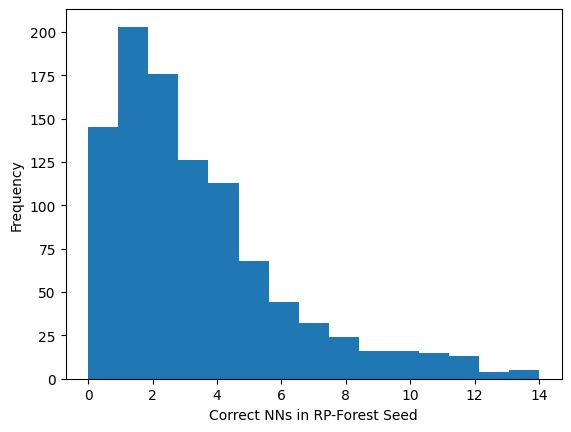

In [150]:
plt.hist(len_overlaps, bins=15)

plt.xlabel("Correct NNs in RP-Forest Seed")
plt.ylabel("Frequency")

In [151]:
print(np.mean(len_overlaps))

3.152


In [ ]:
# 15 @ 100
len_overlaps_at_100 = []
for id in np.random.choice(1_000_000, size=1000):
    dot_sims = np.dot(data, data[id])
    ord = np.flip(np.argsort(dot_sims))[1:101]
    overlap = np.intersect1d(ord, nn15_seed[id])
    len_overlaps_at_100.append(len(overlap))
    

Text(0, 0.5, 'Frequency')

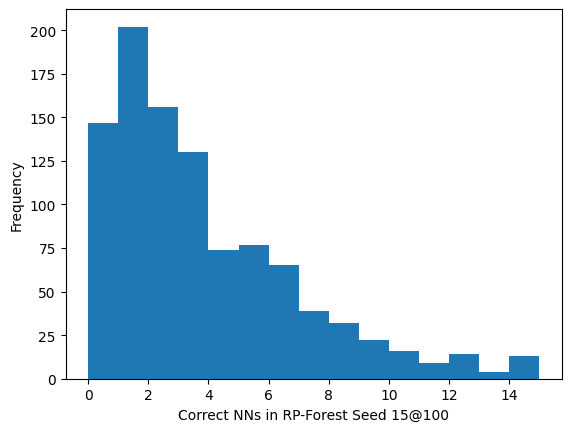

In [153]:
plt.hist(len_overlaps_at_100, bins=15)

plt.xlabel("Correct NNs in RP-Forest Seed 15@100")
plt.ylabel("Frequency")